In [38]:
import kagglehub

path = kagglehub.dataset_download(
    "jp797498e/twitter-entity-sentiment-analysis"
)

print(path)



Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
/kaggle/input/twitter-entity-sentiment-analysis


In [39]:
import os
print(os.listdir(path))


['twitter_validation.csv', 'twitter_training.csv']


In [40]:
import pandas as pd
df = pd.read_csv(
    os.path.join(path, "twitter_training.csv"),
    header=None
)

df.head()



,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [41]:
df.columns

Index([0, 1, 2, 3], dtype='int64')

In [42]:
df.columns = [
    "Tweet_ID",
    "Entity",
    "Sentiment",
    "Tweet"
]

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [44]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 74682
Columns : 4


In [45]:
df.isnull().sum()

,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,686


In [46]:
df.dropna(inplace=True)

df.isnull().sum()

,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,0


In [47]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 2340


In [48]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [49]:
df.columns = [
    "Tweet_ID",
    "Entity",
    "Sentiment",
    "Tweet"
]
df["Sentiment"].value_counts()

,count
Sentiment,
Negative,21698
Positive,19713
Neutral,17708
Irrelevant,12537


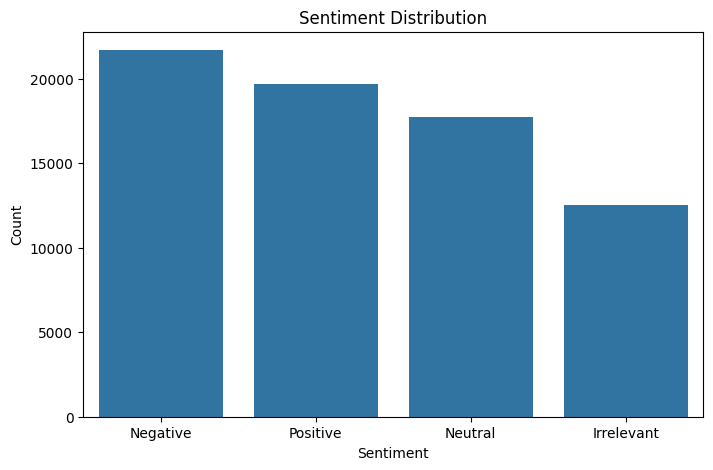

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="Sentiment",
    data=df,
    order=df["Sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [51]:
df = df[["Tweet", "Sentiment"]]

df.head()

,Tweet,Sentiment
0,im getting on borderlands and i will murder yo...,Positive
1,I am coming to the borders and I will kill you...,Positive
2,im getting on borderlands and i will kill you ...,Positive
3,im coming on borderlands and i will murder you...,Positive
4,im getting on borderlands 2 and i will murder ...,Positive


In [52]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [53]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

In [54]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+", "", text)


    text = re.sub(r"@\w+", "", text)


    text = re.sub(r"#", "", text)


    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )


    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


In [55]:
df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

df.head()

,Tweet,Sentiment,Clean_Tweet
0,im getting on borderlands and i will murder yo...,Positive,im getting borderland murder
1,I am coming to the borders and I will kill you...,Positive,coming border kill
2,im getting on borderlands and i will kill you ...,Positive,im getting borderland kill
3,im coming on borderlands and i will murder you...,Positive,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,Positive,im getting borderland murder


In [56]:
df[['Tweet','Clean_Tweet']].head(10)

,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder
5,im getting into borderlands and i can murder y...,im getting borderland murder
6,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...
7,So I spent a couple of hours doing something f...,spent couple hour something fun dont know im h...
8,So I spent a few hours doing something for fun...,spent hour something fun dont know im huge bor...
9,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...


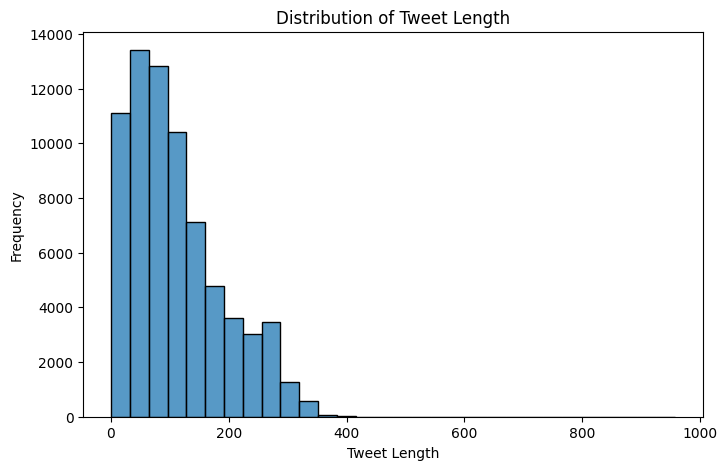

In [57]:
df['Tweet_Length'] = df['Tweet'].astype(str).apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df['Tweet_Length'], bins=30)

plt.title("Distribution of Tweet Length")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()


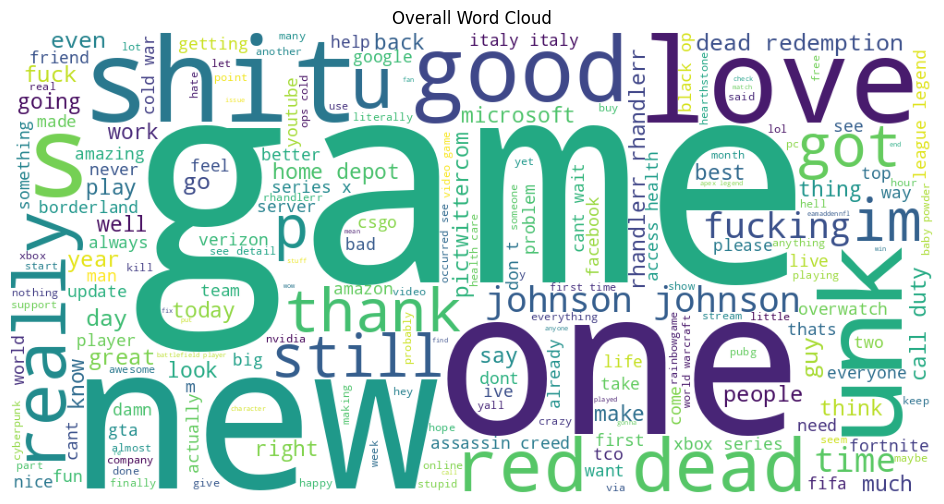

In [58]:
from wordcloud import WordCloud

text = " ".join(df['Clean_Tweet'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Overall Word Cloud")

plt.show()

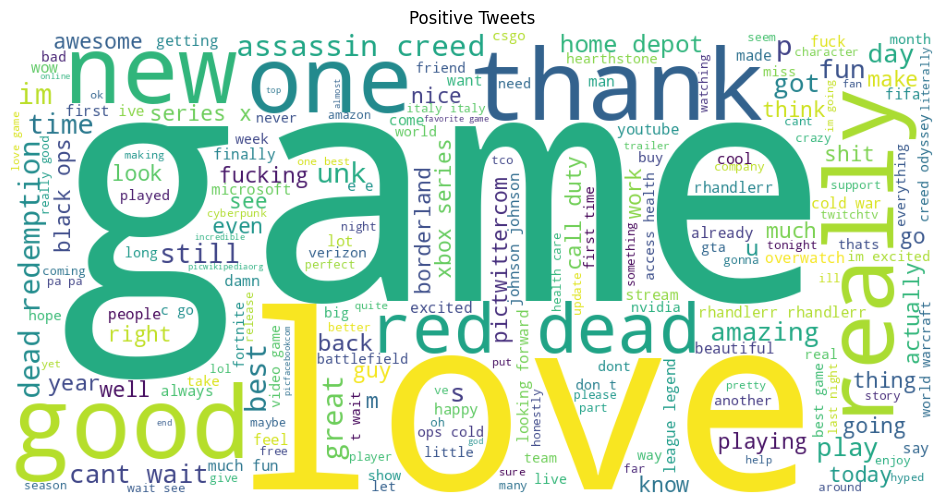

In [59]:
positive = " ".join(
    df[df['Sentiment']=="Positive"]['Clean_Tweet']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Tweets")

plt.show()

In [60]:
from collections import Counter

words = " ".join(df['Clean_Tweet']).split()

common = Counter(words).most_common(20)

common_df = pd.DataFrame(
    common,
    columns=['Word','Frequency']
)

common_df

,Word,Frequency
0,game,10222
1,like,4872
2,get,4313
3,im,3721
4,one,3663
5,play,3537
6,good,3471
7,time,3423
8,love,3211
9,really,3209


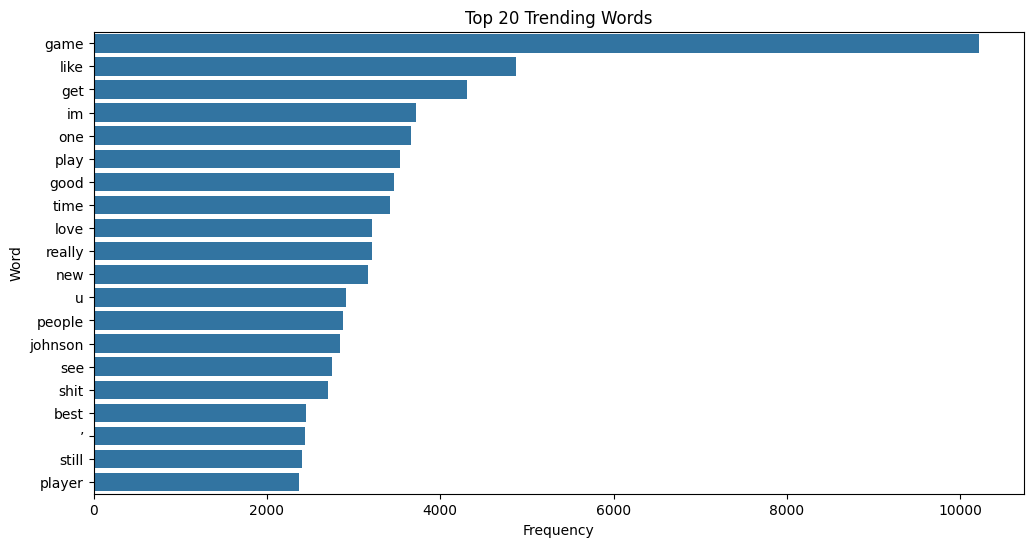

In [61]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=common_df,
    x='Frequency',
    y='Word'
)

plt.title("Top 20 Trending Words")

plt.show()


In [62]:
df['Sentiment'] = df['Sentiment'].replace({
    'Negative':0,
    'Neutral':1,
    'Positive':2,
    'Irrelevant':3
})

df.head()

/tmp/ipykernel_547/3434314974.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sentiment'] = df['Sentiment'].replace({


,Tweet,Sentiment,Clean_Tweet,Tweet_Length
0,im getting on borderlands and i will murder yo...,2,im getting borderland murder,53
1,I am coming to the borders and I will kill you...,2,coming border kill,51
2,im getting on borderlands and i will kill you ...,2,im getting borderland kill,50
3,im coming on borderlands and i will murder you...,2,im coming borderland murder,51
4,im getting on borderlands 2 and i will murder ...,2,im getting borderland murder,57


In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df['Clean_Tweet'])

y = df['Sentiment']

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [65]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy :", accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy : 0.6763885012559308
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      4340
           1       0.62      0.65      0.63      3542
           2       0.69      0.70      0.69      3943
           3       0.67      0.53      0.59      2507

    accuracy                           0.68     14332
   macro avg       0.67      0.66      0.66     14332
weighted avg       0.68      0.68      0.67     14332



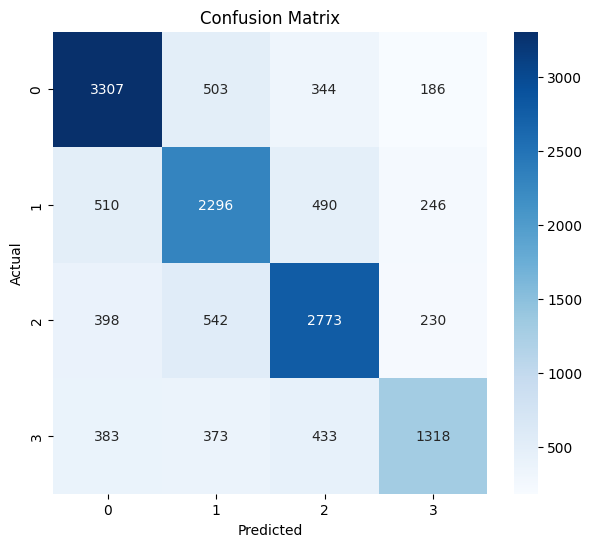

In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

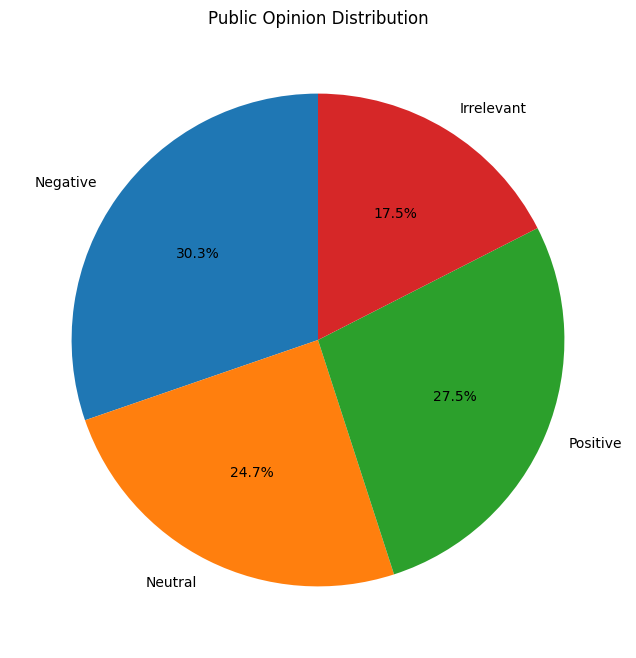

In [68]:
labels = ['Negative','Neutral','Positive','Irrelevant']

sizes = df['Sentiment'].value_counts().sort_index()

plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Public Opinion Distribution")

plt.show()

In [69]:
def predict_sentiment(comment):

    comment = clean_text(comment)

    vector = tfidf.transform([comment])

    prediction = lr.predict(vector)[0]

    labels = {
        0:'Negative',
        1:'Neutral',
        2:'Positive',
        3:'Irrelevant'
    }

    print("Predicted Sentiment :", labels[prediction])

In [70]:
predict_sentiment(
    "This phone is amazing. I love its camera and battery life!"
)

Predicted Sentiment : Positive


In [71]:
predict_sentiment(
    "Worst product ever. Completely disappointed."
)


Predicted Sentiment : Negative
